In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/williamson5/nsl-kdd-dataset/DrDoS_DNS.csv')

print(df.head())

   protocol  flow_duration  total_forward_packets  total_backward_packets  \
0        17           2468                      4                       0   
1        17            133                      4                       0   
2        17          33509                    200                       0   
3        17         288495                    200                       0   
4        17              9                      2                       0   

   total_forward_packets_length  total_backward_packets_length  \
0                        1580.0                            0.0   
1                        5888.0                            0.0   
2                       88000.0                            0.0   
3                       88000.0                            0.0   
4                        2062.0                            0.0   

   forward_packet_length_mean  backward_packet_length_mean  \
0                       395.0                          0.0   
1               

In [2]:
df.columns

Index(['protocol', 'flow_duration', 'total_forward_packets',
       'total_backward_packets', 'total_forward_packets_length',
       'total_backward_packets_length', 'forward_packet_length_mean',
       'backward_packet_length_mean', 'forward_packets_per_second',
       'backward_packets_per_second', 'forward_iat_mean', 'backward_iat_mean',
       'flow_iat_mean', 'flow_packets_per_seconds', 'flow_bytes_per_seconds',
       'label'],
      dtype='object')

In [3]:
X = df.drop('label', axis=1)
y = df['label']

In [4]:
df['label'].value_counts()

label
DrDoS_DNS    32797
BENIGN        1128
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
y_pred = model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00       219
   DrDoS_DNS       1.00      1.00      1.00      6566

    accuracy                           1.00      6785
   macro avg       1.00      1.00      1.00      6785
weighted avg       1.00      1.00      1.00      6785



In [9]:
sample = X_test.iloc[[0]]   # keep as DataFrame, NOT array

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: ['DrDoS_DNS']


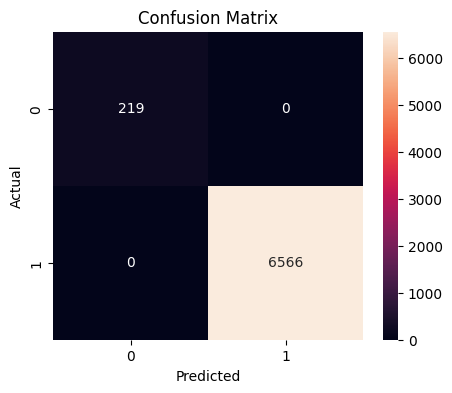

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

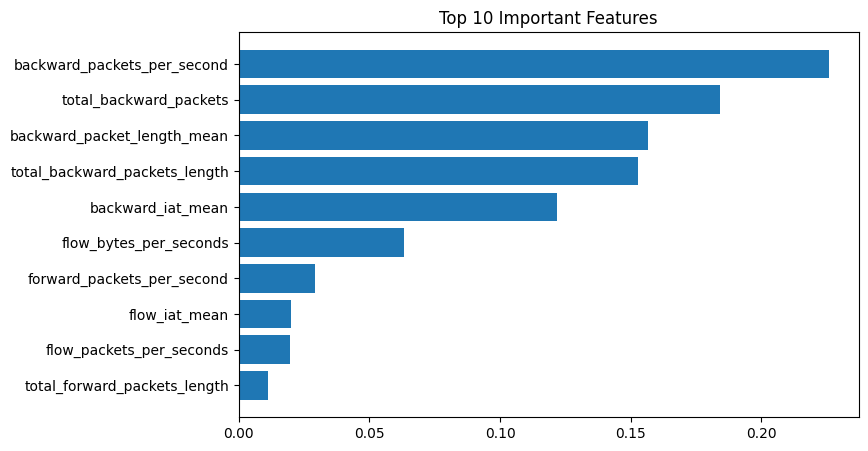

In [11]:
import numpy as np
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Important Features")
plt.show()

In [12]:
sample = X_test.iloc[[0]]   # keep DataFrame format

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: ['DrDoS_DNS']


In [13]:
print("MODEL SUMMARY")
print("----------------")
print("Accuracy: 100% (from your result)")
print("Model: Random Forest")
print("Dataset: DrDoS DNS Attack Detection")

MODEL SUMMARY
----------------
Accuracy: 100% (from your result)
Model: Random Forest
Dataset: DrDoS DNS Attack Detection
